# Introduction to Scikit-Learn

Scikit-learn is a powerful Python library used for:
- Machine Learning
- Data preprocessing
- Model training
- Evaluation

It provides simple and efficient tools for:
✔ Regression  
✔ Classification  
✔ Clustering  

We will use it to build and evaluate models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Create a simple dataset
data = {
    'Hours_Studied': [1,2,3,4,5,6,7,8],
    'Marks': [35,40,50,55,65,70,75,85],
    'Pass': [0,0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Marks,Pass
0,1,35,0
1,2,40,0
2,3,50,0
3,4,55,1
4,5,65,1
5,6,70,1
6,7,75,1
7,8,85,1


# Supervised Learning

Supervised learning means:
👉 Model learns from labeled data

Two types:

## 1. Regression
- Predicts continuous values
- Example: Marks prediction

## 2. Classification
- Predicts categories
- Example: Pass/Fail


In [4]:
# Features and Target
X = df[['Hours_Studied']]
y_reg = df['Marks']
y_clf = df['Pass']

# Train-Test Split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Model Evaluation Metrics

## 1. R-squared (R²)
- Measures how well model fits data
- Value between 0 and 1
- Higher = better

## 2. MAE (Mean Absolute Error)
- Average error between predicted and actual values
- Lower = better

## 3. Confusion Matrix
Used in classification:
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

## 4. Accuracy
Accuracy = Correct Predictions / Total Predictions

In [5]:
# Model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train_reg)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test_reg, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr))

R2 Score: 0.9882222222222222
MAE: 1.1999999999999993


In [6]:
# Model
log_reg = LogisticRegression()

# Train
log_reg.fit(X_train, y_train_clf)

# Predict
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_log))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]


In [7]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train_clf)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test_clf, y_pred_dt))

Decision Tree Accuracy: 1.0


In [8]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train_clf)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test_clf, y_pred_rf))

Random Forest Accuracy: 1.0


In [10]:
new_data = pd.DataFrame({'Hours_Studied': [5]})

print("Linear Regression Prediction (Marks):", lr.predict(new_data))
print("Logistic Regression Prediction (Pass/Fail):", log_reg.predict(new_data))

Linear Regression Prediction (Marks): [63.15]
Logistic Regression Prediction (Pass/Fail): [1]


Text(0.5, 1.0, 'Linear Regression')

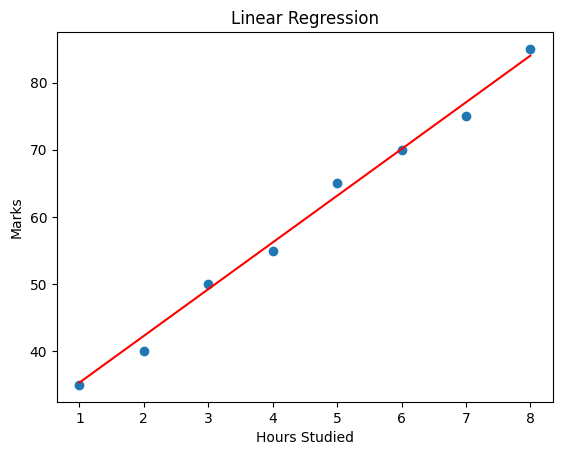

In [13]:
# Plot Regression Line
plt.scatter(X, y_reg)
plt.plot(X, lr.predict(X), color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Linear Regression")
plt.show()